# 基础流程
1. 理论框架：这个算法解决什么问题
2. 底层逻辑：它到底在优化什么
3. 数学表达：只讲比赛够用的公式
4. sklearn 实践：完整代码
5. 代码解读：每一段为什么这么写
6. 结果解读：指标、图像、模型表现
7. 常见错误：比赛中容易踩的坑
8. 算法标准模板：以后直接放进你的算法文档
9. 作业：巩固当天内容

# Day 1:线性回归

X shape: (442, 10)
y shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.23

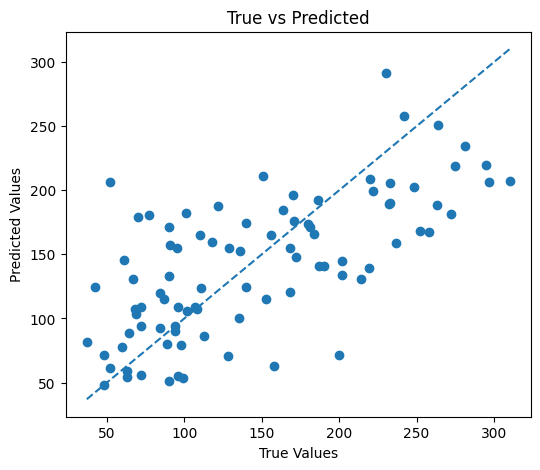

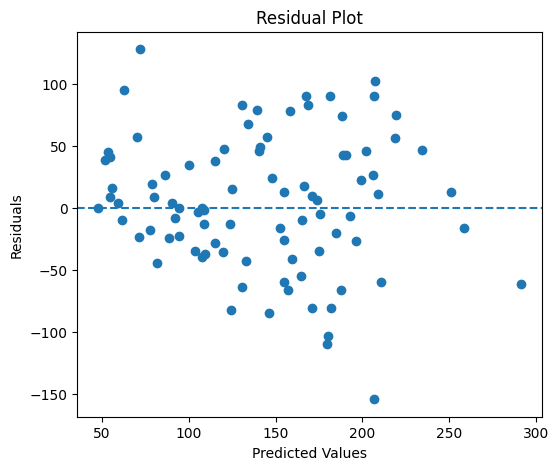

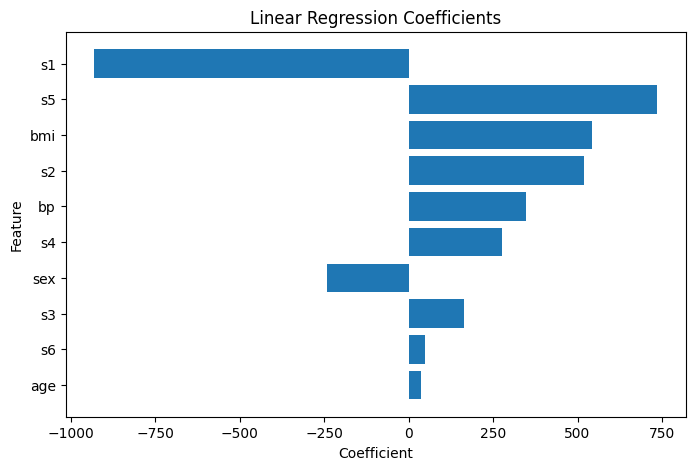

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes #导入数据集
from sklearn.model_selection import train_test_split #导入训练集测试集划分工具
from sklearn.linear_model import LinearRegression #导入线性回归模型
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score #导入评价指标：均方误差MSE，平均绝对误差MAE，R方

#1.加载数据
data=load_diabetes()
X=data.data
y=data.target

print("X shape:",X.shape)
print("y shape:",y.shape)
print("Feature names:",data.feature_names)

#2.转成DataFrame
X_df=pd.DataFrame(X,columns=data.feature_names)
y_series=pd.Series(y,name="target")

df=pd.concat([X_df,y_series],axis=1) #把 X_df 和 y_series 按列拼接起来

print(df.head())
print(df.describe())

#3.划分训练集和测试集
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)

#4.建立并训练模型
model = LinearRegression()

model.fit(X_train, y_train)

#5.查看模型参数
print("Intercept:", model.intercept_) #model.intercept_:截距
print("Coefficients:", model.coef_) #model.coef_:系数

coef_df = pd.DataFrame({
    "feature": data.feature_names,
    "coef": model.coef_
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print(coef_df)

#6.预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#7.计算评价指标
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

print("Train R2:", train_r2)
print("Test R2:", test_r2)


#8.可视化
#图一：真实值vs预测值
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_test_pred)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

#完美预测线，斜率为 1 的线
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted")
plt.show()

#图二：残差图
residuals = y_test - y_test_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0, linestyle="--") #画一条 y=0 的水平线

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#图三：系数图
plt.figure(figsize=(8, 5))
plt.barh(coef_df["feature"], coef_df["coef"]) #barh(y,x):水平条形图
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients")
plt.gca().invert_yaxis() #意思是把 y 轴反过来，让排序第一的特征显示在最上面
plt.show()

## 算法名称：线性回归 Linear Regression

一、适用任务
线性回归适用于回归问题，即目标变量为连续数值的预测任务，例如房价预测、销量预测、疾病进展预测、收入预测等。

二、核心思想
线性回归假设目标变量可以由多个特征的线性组合近似表示。模型通过学习各个特征对应的系数和截距，建立从特征 X 到目标 y 的映射关系。

三、数学形式
预测函数：
ŷ = w1x1 + w2x2 + ... + wpxp + b

其中，ŷ 为预测值，x1 至 xp 为特征，w1 至 wp 为特征系数，b 为截距。

四、优化目标
线性回归通过最小化真实值与预测值之间的残差平方和来估计参数：
min Σ(yi - ŷi)²

五、sklearn 实现
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

六、常用评价指标
MSE：平均平方误差，对大误差更敏感。
RMSE：均方根误差，与目标变量单位一致，更容易解释。
MAE：平均绝对误差，直观且对异常值不如 MSE 敏感。
R²：决定系数，用于衡量模型对目标变量波动的解释程度，最高为 1，也可能小于 0。

七、关键可视化
1. 真实值 vs 预测值图：观察预测结果是否接近理想 y=x 直线。
2. 残差图：观察残差是否随机分布在 0 附近，判断模型是否存在系统性误差。
3. 系数图：观察不同特征在线性模型中的方向和相对影响大小。

八、优点
1. 模型简单，训练速度快。
2. 可解释性强，适合作为 baseline。
3. 适合特征与目标近似线性关系的数据。
4. 便于分析特征与目标之间的预测关联。

九、缺点
1. 表达能力有限，难以刻画复杂非线性关系。
2. 对异常值较敏感。
3. 存在多重共线性时，系数可能不稳定。
4. 如果特征量纲不同，直接比较系数大小可能误导。

十、比赛使用建议
在线性回归用于比赛建模时，通常将其作为 baseline 模型。若线性回归表现较差，可以进一步尝试 Ridge、Lasso、决策树、随机森林、GBDT 等模型。报告中应同时展示训练集和测试集指标，并结合真实值-预测值图和残差图分析模型表现。解释系数时应谨慎，不能直接将预测关联解释为因果关系。

今天我完成了 diabetes 数据集上的线性回归建模。该任务属于回归问题，目标是根据 10 个特征预测疾病进展指标。线性回归假设目标变量可以由特征的线性组合近似表示，并通过最小化残差平方和学习模型的系数和截距。模型在训练集上的 RMSE 为 53.56，测试集上的 RMSE 为 53.85；训练集 R² 为 0.528，测试集 R² 为 0.453。结果说明模型没有明显过拟合，但整体预测能力一般，只能解释测试集中约 45.3% 的目标变量波动。True vs Predicted 图显示，散点整体沿 y=x 方向分布，但离虚线较分散，且模型对高真实值样本存在低估倾向。残差图显示残差大致围绕 0 分布，但存在少数大误差点。总体来看，线性回归适合作为 baseline，优点是简单、可解释，缺点是表达能力有限，对非线性关系和异常点较敏感。下一步可以学习 Ridge 和 Lasso，通过正则化提高模型稳定性和泛化能力。

# Day 2:Ridge/Lasso与正则化

X shape: (442, 10)
y shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
results_df:
               model  train_rmse  test_rmse  train_mae   test_mae  train_r2  \
0  LinearRegression   53.558843  53.853446  43.483504  42.794095  0.527919   
1   Ridge_alpha_0.1   53.972063  53.446112  43.913006  42.996932  0.520607   
2     Ridge_alpha_1   58.208098  55.474462  48.805194  46.138858  0.442403   
3    Ridge_alpha_10   71.302076  66.662978  60.956061  58.030756  0.163322   
4  Lasso_alpha_0.01   53.638429  53.652208  43.549514  42.831847  0.526515   
5   Lasso_alpha_0.1   54.178024  52.897954  44.272664  42.854428  0.516941   
6     Lasso_alpha_1   62.134974  58.340172  52.958780  49.730328  0.364631   

    test_r2  coef_abs_mean  zero_coef_count  
0  0.452603     384.315951                0  
1  0.460852     207.953698                0  
2  0.419153     124.761888                0  
3  0.161226      33.991162                0  
4  0.456686     26

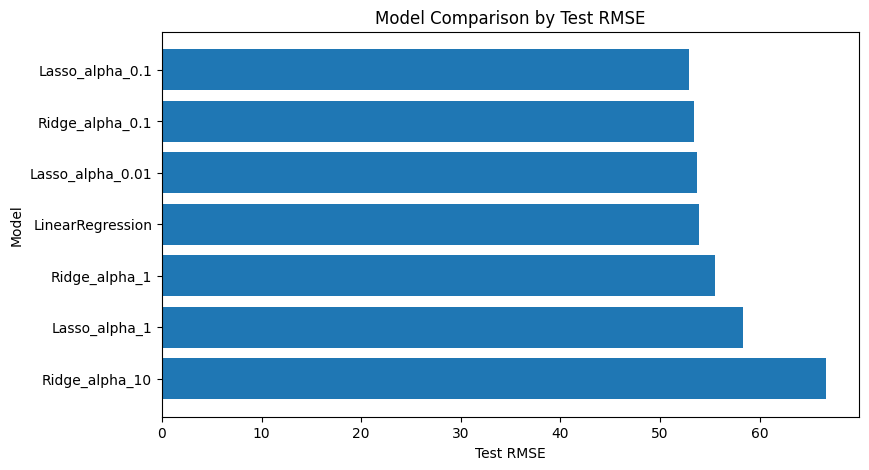

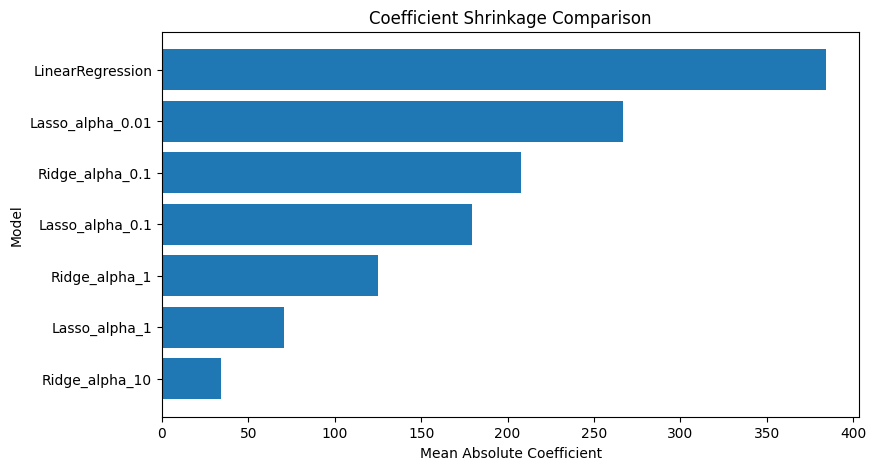

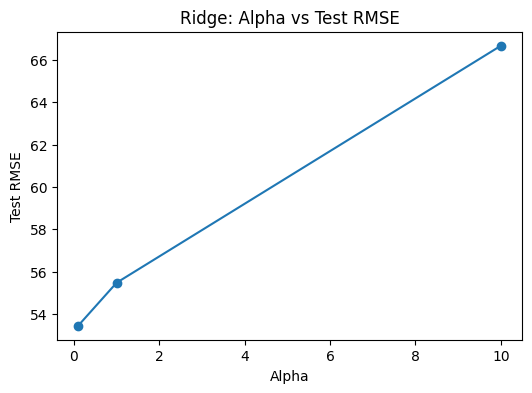

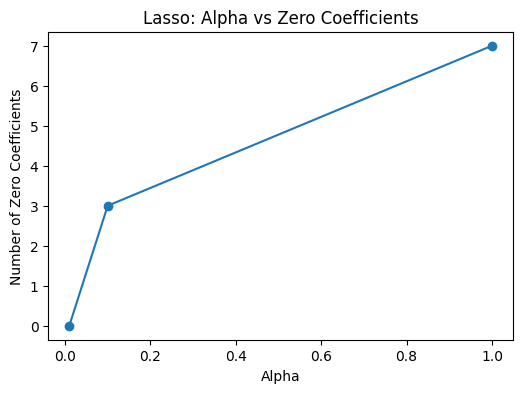

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso #Ridge：岭回归，L2正则化；Lasso：套索回归，L1正则化
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#1.加载数据
data = load_diabetes()

X = data.data
y = data.target

feature_names = data.feature_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", feature_names)

#2.划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#3.建立多个模型
models = {
    "LinearRegression": LinearRegression(),
    "Ridge_alpha_0.1": Ridge(alpha=0.1),
    "Ridge_alpha_1": Ridge(alpha=1),
    "Ridge_alpha_10": Ridge(alpha=10),
    "Lasso_alpha_0.01": Lasso(alpha=0.01, max_iter=10000),#alpha=0.1：L1 正则化强度；max_iter=10000：最大迭代次数
    "Lasso_alpha_0.1": Lasso(alpha=0.1, max_iter=10000),
    "Lasso_alpha_1": Lasso(alpha=1, max_iter=10000)
}

#4.训练、预测、评价
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    #计算模型系数绝对值平均大小。Ridge/Lasso的核心就是压缩系数，如果正则化生效，通常alpha越大，coef_abs_mean越小
    coef_abs_mean = np.mean(np.abs(model.coef_)) #model.coed_:模型学到的所有系数
    #统计系数等于0的个数。Lasso的特点是可能把某些系数压成0，如果某个特征系数为0，则该特征被Lasso暂时排除在模型之外(Lasso的特征选择作用)
    zero_coef_count = np.sum(model.coef_ == 0) #统计系数等于0的个数

    results.append({
        "model": name,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "coef_abs_mean": coef_abs_mean, 
        "zero_coef_count": zero_coef_count
    })

results_df = pd.DataFrame(results)
print("results_df:\n",results_df)

#5.提取系数
coef_df = pd.DataFrame({
    "feature": feature_names
})

for name, model in models.items():
    coef_df[name] = model.coef_

print("coef_df:\n",coef_df)

#6.可视化诊断

#1.不同模型 Test RMSE 对比图(谁预测最好?)
# Test RMSE 越小，模型测试集误差越小；
# 排在最上面的模型表现最好；
# 如果 Ridge / Lasso 的 RMSE 小于 LinearRegression，说明正则化有提升。
plot_df = results_df.sort_values("test_rmse") #按照 test_rmse 从小到大排序

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_df["model"], plot_df["test_rmse"])

ax.set_xlabel("Test RMSE")
ax.set_ylabel("Model")
ax.set_title("Model Comparison by Test RMSE")
#反转Y轴，RMSE最小的那个模型就会被移到图表的正上方（第一排）
ax.invert_yaxis()

plt.show()

#2.不同模型系数绝对值均值对比图(谁压缩系数更强?)
# 系数绝对值均值越小，说明模型系数整体越被压缩；
# Ridge / Lasso 的 alpha 越大，通常系数越小；
# 如果系数过小，可能出现欠拟合。
plot_df = results_df.sort_values("coef_abs_mean", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_df["model"], plot_df["coef_abs_mean"])

ax.set_xlabel("Mean Absolute Coefficient")
ax.set_ylabel("Model")
ax.set_title("Coefficient Shrinkage Comparison")

ax.invert_yaxis()

plt.show()

#3.Ridge 不同 alpha 的 Test RMSE 曲线(Ridge 的 alpha 怎么影响误差?)
# alpha 改变后，测试集误差怎么变化；
# alpha 太小可能正则化不够；
# alpha 太大可能欠拟合；
# 最优 alpha 应该让测试集 RMSE 较低。
ridge_df = results_df[results_df["model"].str.contains("Ridge")].copy() #从 results_df 中筛选出 Ridge 模型

ridge_df["alpha"] = ridge_df["model"].str.extract(r"alpha_(.*)").astype(float) #从模型名字中提取 alpha

ridge_df = ridge_df.sort_values("alpha")

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(ridge_df["alpha"], ridge_df["test_rmse"], marker="o")

ax.set_xlabel("Alpha")
ax.set_ylabel("Test RMSE")
ax.set_title("Ridge: Alpha vs Test RMSE")

plt.show()

#4.Lasso 零系数数量图(Lasso 的 alpha 怎么影响特征选择?)
# alpha 越大，Lasso 越可能把更多系数压成 0；
# 零系数越多，模型越稀疏；
# 但如果太多特征被压成 0，可能欠拟合。
lasso_df = results_df[results_df["model"].str.contains("Lasso")].copy()

lasso_df["alpha"] = lasso_df["model"].str.extract(r"alpha_(.*)").astype(float)

lasso_df = lasso_df.sort_values("alpha")

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(lasso_df["alpha"], lasso_df["zero_coef_count"], marker="o")

ax.set_xlabel("Alpha")
ax.set_ylabel("Number of Zero Coefficients")
ax.set_title("Lasso: Alpha vs Zero Coefficients")

plt.show()

图一：谁预测最好？  
Lasso_alpha_0.1 的 Test RMSE 最小，说明在当前测试集划分下，它的预测误差最低。 

图二：谁压缩系数更强？   
LinearRegression 的系数绝对值均值最大；  
Ridge 和 Lasso 都压缩了系数；  
Ridge_alpha_10 和 Lasso_alpha_1 压缩最强。  

图三：Ridge 的 alpha 怎么影响误差？  
Ridge 中 alpha 从 0.1 增大到 10 后，Test RMSE 持续上升，说明 Ridge 正则化过强会使模型欠拟合。  

图 4：Lasso 的 alpha 怎么影响特征选择？  
Lasso 中 alpha 增大后，零系数数量从 0 增加到 7，说明 Lasso 正则化越强，筛掉的特征越多。

在本次实验中，Lasso_alpha_0.1 取得最低 Test RMSE，并且通过 L1 正则化将 3 个特征系数压缩为 0，实现了一定程度的特征选择。相比之下，Ridge_alpha_10 和 Lasso_alpha_1 正则化过强，系数被明显压缩，测试误差变大，表现出欠拟合倾向。

## 算法名称：Ridge 回归与 Lasso 回归

一、适用任务  
Ridge 和 Lasso 都适用于回归任务，尤其适用于线性回归中存在多重共线性、特征较多、模型系数不稳定或需要控制过拟合风险的场景。

二、核心思想  
普通线性回归只最小化训练误差，而 Ridge 和 Lasso 在训练误差基础上加入系数惩罚项，通过限制系数大小来降低模型复杂度，提高模型稳定性和泛化能力。

三、数学形式  
普通线性回归：  
min Σ(yi - ŷi)²

Ridge 回归：  
min Σ(yi - ŷi)² + αΣwj²

Lasso 回归：  
min Σ(yi - ŷi)² + αΣ|wj|

其中，α 是正则化强度。α 越大，对系数的惩罚越强。  

四、Ridge 与 Lasso 的区别  
Ridge 使用 L2 正则化，主要作用是压缩系数，使系数整体变小，但通常不会将系数压缩为 0。它适合处理多重共线性和希望保留大部分特征的情况。

Lasso 使用 L1 正则化，既可以压缩系数，也可能将部分系数压缩为 0，因此具有特征选择作用。它适合特征较多，并希望得到较稀疏模型的情况。

五、sklearn 实现  
from sklearn.linear_model import Ridge, Lasso  

ridge = Ridge(alpha=1)  
ridge.fit(X_train, y_train)  
ridge_pred = ridge.predict(X_test)  

lasso = Lasso(alpha=0.1, max_iter=10000)  
lasso.fit(X_train, y_train)  
lasso_pred = lasso.predict(X_test)  

六、关键参数  
alpha：正则化强度。alpha 越大，系数惩罚越强；alpha 过小接近普通线性回归，alpha 过大可能导致欠拟合。  
max_iter：Lasso 等迭代优化模型的最大迭代次数，用于避免模型未收敛。  

七、常用评价指标  
RMSE：衡量预测误差规模。  
MAE：衡量平均绝对误差。  
R²：衡量模型解释目标变量波动的能力。  
coef_abs_mean：观察系数整体大小，判断正则化是否压缩系数。  
zero_coef_count：观察 Lasso 是否产生稀疏解，即是否将部分特征系数压缩为 0。  

八、关键可视化  
1. 不同模型 Test RMSE 对比图：比较 LinearRegression、Ridge、Lasso 的预测误差。  
2. 系数绝对值均值对比图：观察正则化对系数大小的压缩效果。  
3. alpha 与 Test RMSE 曲线：观察正则化强度变化对模型泛化表现的影响。  
4. Lasso 零系数数量图：观察 Lasso 的特征选择效果。  

九、优点  
Ridge 的优点是能缓解多重共线性，提高模型稳定性，并保留所有特征。   
Lasso 的优点是能产生稀疏系数，具有特征选择能力，便于模型解释。  

十、缺点  
Ridge 不能直接进行特征选择，所有特征通常都会保留。  
Lasso 在特征强相关时可能不稳定，可能随机选择其中一个相关特征。  
二者都依赖 alpha 的选择，alpha 不合适会导致正则化不足或欠拟合。  

十一、比赛使用建议  
Ridge 和 Lasso 常用于线性回归 baseline 的改进版本。建模时应先与普通 LinearRegression 比较，再通过验证集或交叉验证选择合适的 alpha。报告中应说明正则化项的作用，并结合 RMSE、R²、系数变化和零系数数量解释模型表现。不要简单认为正则化越强越好。

# Day 3:交叉验证Cross Validation

X shape: (442, 10)
y shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
              model  cv_rmse_mean  cv_rmse_std
0  LinearRegression     54.848941     2.641094
1   Ridge_alpha_0.1     54.843463     2.450555
2     Ridge_alpha_1     58.564192     1.845884
3    Ridge_alpha_10     70.765607     2.813848
4  Lasso_alpha_0.01     54.868367     2.490172
5   Lasso_alpha_0.1     54.926335     2.610106
6     Lasso_alpha_1     62.374455     2.109187


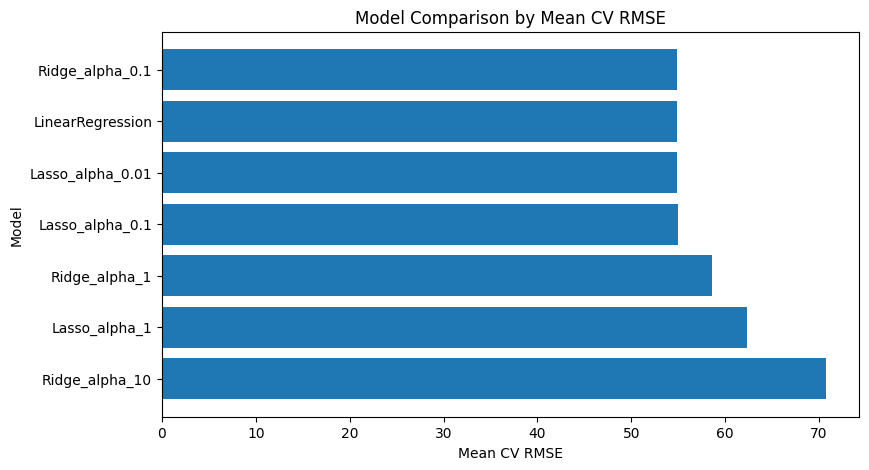

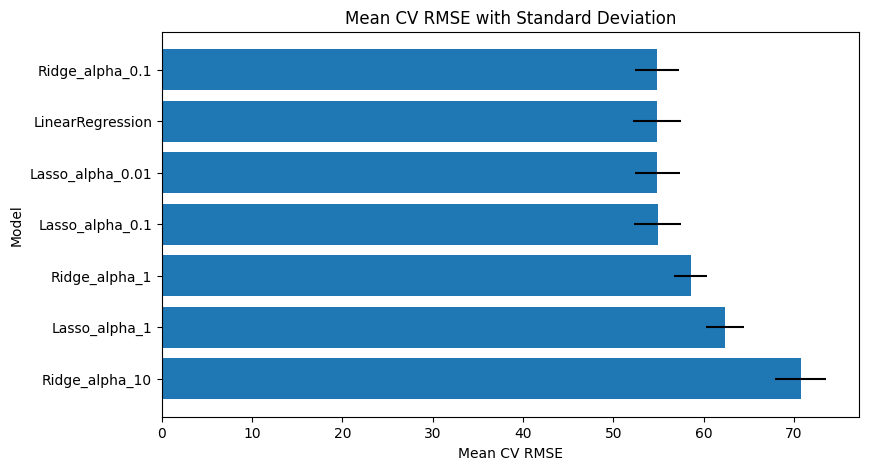

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
#cross_val_score：自动进行交叉验证并返回每一折的分数
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error

#1.加载数据
data = load_diabetes()

X = data.data
y = data.target

feature_names = data.feature_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", feature_names)

#2.建立模型
models = {
    "LinearRegression": LinearRegression(),
    "Ridge_alpha_0.1": Ridge(alpha=0.1),
    "Ridge_alpha_1": Ridge(alpha=1),
    "Ridge_alpha_10": Ridge(alpha=10),
    "Lasso_alpha_0.01": Lasso(alpha=0.01, max_iter=10000),
    "Lasso_alpha_0.1": Lasso(alpha=0.1, max_iter=10000),
    "Lasso_alpha_1": Lasso(alpha=1, max_iter=10000)
}

#3.设置KFold
kf = KFold(
    n_splits=5, #5折交叉验证
    shuffle=True, #划分前打乱数据，时间序列数据不能随便shuffle
    random_state=42
)

#4.使用 cross_val_score 做交叉验证
cv_results = []

for name, model in models.items():
    neg_mse_scores = cross_val_score(
        model,
        X,
        y,
        cv=kf, #使用前面定义的kfold划分方式
        scoring="neg_mean_squared_error" #使用负均方误差作为评分
    )

    rmse_scores = np.sqrt(-neg_mse_scores)

    cv_results.append({
        "model": name,
        "cv_rmse_mean": rmse_scores.mean(),
        "cv_rmse_std": rmse_scores.std(),
        "cv_rmse_scores": rmse_scores
    })

cv_results_df = pd.DataFrame(cv_results)

print(cv_results_df[["model", "cv_rmse_mean", "cv_rmse_std"]])

#5.可视化诊断

#图1：不同模型 CV RMSE 平均值对比图
#回答哪个模型在交叉验证下平均误差最低？
plot_df = cv_results_df.sort_values("cv_rmse_mean")

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_df["model"], plot_df["cv_rmse_mean"])

ax.set_xlabel("Mean CV RMSE")
ax.set_ylabel("Model")
ax.set_title("Model Comparison by Mean CV RMSE")

ax.invert_yaxis()

plt.show()

#图2：不同模型 CV RMSE 均值 + 标准差图
#回答哪个模型平均误差低？哪个模型表现更稳定？
plot_df = cv_results_df.sort_values("cv_rmse_mean")

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    plot_df["model"],
    plot_df["cv_rmse_mean"],
    xerr=plot_df["cv_rmse_std"] #画误差线，表示不同折之间 RMSE 的波动
)

ax.set_xlabel("Mean CV RMSE")
ax.set_ylabel("Model")
ax.set_title("Mean CV RMSE with Standard Deviation")

ax.invert_yaxis()

plt.show()


## 选择某个模型的最佳参数

In [2]:
#1.RidgeCV
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-4, 4, 50)

ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_cv.fit(X, y)

print("Best Ridge alpha:", ridge_cv.alpha_)

#2.LassoCV
from sklearn.linear_model import LassoCV

alphas = np.logspace(-4, 1, 50)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=10000,
    random_state=42
)

lasso_cv.fit(X, y)

print("Best Lasso alpha:", lasso_cv.alpha_)


Best Ridge alpha: 0.0004498432668969444
Best Lasso alpha: 0.00339322177189533


## 用GridSearchCV做通用调参

In [ ]:
#后面模型复杂后，比如随机森林、SVM、XGBoost，就不会有 RandomForestCV 这种专门类了
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = {
    "alpha": np.logspace(-4, 4, 50)
}

grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best CV score:", np.sqrt(-grid.best_score_))

## 方法名称：交叉验证 Cross Validation

一、适用场景  
交叉验证适用于模型评估和模型选择，尤其当样本量有限、单次 train/test split 结果不稳定时，可以更稳健地估计模型泛化表现。

二、核心思想  
交叉验证不只进行一次训练集/验证集划分，而是将数据划分为 K 份，每次使用其中 1 份作为验证集，其余 K-1 份作为训练集，重复 K 次，使每一份数据都被用作一次验证集。最终根据 K 次验证结果的平均值和标准差评价模型表现。

三、K 折交叉验证流程  
1. 将数据划分为 K 个 fold。  
2. 第 1 次使用 Fold 1 验证，其余 fold 训练。  
3. 第 2 次使用 Fold 2 验证，其余 fold 训练。  
4. 重复直到每个 fold 都作为验证集一次。  
5. 得到 K 个验证分数。  
6. 计算平均分和标准差。  

四、sklearn 实现  
from sklearn.model_selection import KFold, cross_val_score  

kf = KFold(n_splits=5, shuffle=True, random_state=42)  

scores = cross_val_score(  
    model,  
    X,  
    y,  
    cv=kf,  
    scoring="neg_mean_squared_error"  
)  

rmse_scores = np.sqrt(-scores)  

五、关键参数  
n_splits：折数，常用 5 或 10。  
shuffle：是否在划分前打乱数据。  
random_state：随机种子，用于保证结果可复现。  
scoring：评价指标，如 neg_mean_squared_error、r2、accuracy、f1 等。  

六、结果解释  
cv_rmse_mean 表示模型在不同划分下的平均预测误差，越小越好。  
cv_rmse_std 表示不同折之间表现波动，越小表示模型越稳定。  
模型选择时不能只看平均误差，也要关注稳定性。  

七、优点   
1. 比单次train/test split 更稳定。  
2. 能更充分利用有限样本。  
3. 适合模型比较和超参数选择。  
4. 可以降低随机划分带来的偶然性。  

八、缺点  
1. 计算成本更高，因为要训练 K 次模型。  
2. 对时间序列、空间数据、分组数据不能随便使用普通 KFold。  
3. 如果预处理没有放进 Pipeline，可能产生数据泄露。  

九、比赛使用建议  
比赛中应优先使用交叉验证进行模型选择和调参，而不是反复使用测试集调参。测试集应尽量只用于最终评估。对于 Ridge、Lasso 等带超参数的模型，可以使用 RidgeCV、LassoCV 或 GridSearchCV 选择参数。  

# Day 4:逻辑回归Logistic Regression

X shape: (569, 30)
y shape: (569,)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Target names: ['malignant' 'benign']
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1: 0.9861111111111112
ROC AUC: 0.9953703703703703
[[41  1]
 [ 1 71]]


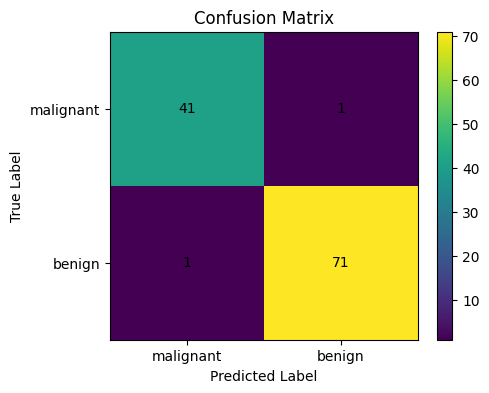

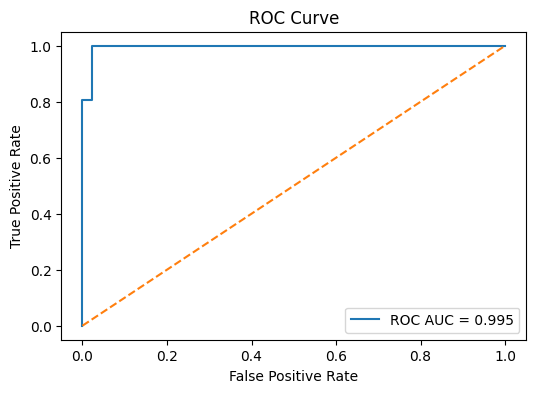

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer #乳腺癌二分类数据集
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #标准化
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, #accuracy准确率=(TP+TN)/(TP+TN+FP+FN)
    precision_score, #precision精确率=TP/(TP+FP)
    recall_score, #recall召回率=TP/(TP+FN)
    f1_score, #F1=2*precision*recall/(precision+recall)
    confusion_matrix,
    roc_auc_score,
    roc_curve #ROC 曲线看 TPR 和 FPR 的权衡
)

#1.加载数据
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", feature_names[:5])
print("Target names:", target_names)

#2.划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #按照y的类别比例分层抽样，在划分训练集和测试集时，尽量保持 y 的类别比例一致
)

#3.标准化
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) #fit_transform: fit:根据数据学习当前对象需要的内部参数; transform:用这些均值和标准差转换训练集
X_test_scaled = scaler.transform(X_test)

#4.建立并训练模型
model = LogisticRegression(max_iter=10000)

model.fit(X_train_scaled, y_train)

#5.预测类别与预测概率
y_pred = model.predict(X_test_scaled) #输出最终类别
y_proba = model.predict_proba(X_test_scaled)[:, 1] #输出正类概率

#6.计算评价指标
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC AUC:", auc)

#7.混淆矩阵 行是真实类别，列是预测类别
cm = confusion_matrix(y_test, y_pred)

print(cm)

#8.可视化诊断
#图一：混淆矩阵图
#对角线为预测正确，非对角线为预测错误
#对角线元素越高越好，表示预测标签等于真实标签的样本越多
fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(cm) #imshow 会根据数值大小给不同格子着色。数值越大，颜色越偏向色条高值区域

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_xticks([0, 1]) #设置横轴和纵轴的刻度位置
ax.set_yticks([0, 1])
ax.set_xticklabels(target_names) #把 0 和 1 换成类别名称；0 → malignant，1 → benign
ax.set_yticklabels(target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=ax) #添加颜色条

plt.show()

#图二：ROC曲线
#TPR=recall=TP/(TP+FN) FPR=FP/(FP+TN)
fpr, tpr, thresholds = roc_curve(y_test, y_proba) #FPR：假阳性率；TPR：真阳性率，也就是 Recall

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()

plt.show()

## 算法名称：逻辑回归 Logistic Regression

一、适用任务  
逻辑回归主要用于分类任务，尤其适用于二分类问题，例如违约预测、疾病诊断、客户流失预测、欺诈识别等。  

二、核心思想  
逻辑回归先对特征进行线性组合，得到 z = w1x1 + w2x2 + ... + wpxp + b，再通过 sigmoid 函数将 z 映射到 0 到 1 之间，得到样本属于正类的概率。最后根据分类阈值将概率转换为类别标签。  

三、数学形式  
线性部分：  
z = w1x1 + w2x2 + ... + wpxp + b  

Sigmoid 函数：  
p = 1 / (1 + exp(-z))  

分类规则：  
若 p >= 0.5，则预测为 1；  
若 p < 0.5，则预测为 0。  

四、sklearn 实现  
from sklearn.linear_model import LogisticRegression  

model = LogisticRegression(max_iter=10000)  
model.fit(X_train_scaled, y_train)  

y_pred = model.predict(X_test_scaled)  
y_proba = model.predict_proba(X_test_scaled)[:, 1]  

五、关键参数  
max_iter：最大迭代次数，用于避免模型未收敛。  
C：正则化强度的倒数，C 越小正则化越强；后续调参时再深入。  
penalty：正则化类型，如 l2、l1 等；当前阶段先默认 l2。  

六、常用评价指标  
Accuracy：整体预测正确率。  
Precision：预测为正类的样本中，真正为正类的比例。
Recall：真实正类样本中，被模型找出来的比例。  
F1：Precision 和 Recall 的调和平均。  
ROC AUC：衡量模型整体区分正负类的能力。  

七、关键可视化  
1. 混淆矩阵：观察 TP、TN、FP、FN，判断模型错在哪里。  
2. ROC 曲线：观察不同阈值下 TPR 和 FPR 的关系，评估模型区分能力。  

八、优点  
1. 模型简单，训练速度快。  
2. 输出概率，便于解释和调整阈值。  
3. 可解释性较强，可以查看特征系数方向。    
4. 适合作为分类任务 baseline。  

九、缺点  
1. 本质是线性分类模型，难以捕捉复杂非线性关系。  
2. 对特征尺度敏感，通常需要标准化。  
3. 类别不平衡时不能只看 Accuracy。  
4. 默认阈值 0.5 不一定适合所有业务场景。  

十、比赛使用建议  
逻辑回归适合作为分类任务 baseline。建模时应标准化特征，并同时报告 Accuracy、Precision、Recall、F1 和 ROC AUC。若类别不平衡，应重点关注 Precision、Recall、F1、AUC，而不是只看 Accuracy。报告中应结合混淆矩阵说明模型主要错误类型。  

# Day 5：KNN + 标准化 + K 值选择

X shape: (569, 30)
y shape: (569,)
Target names: ['malignant' 'benign']
        model  accuracy  precision    recall        f1   roc_auc
0     KNN_raw  0.912281   0.942857  0.916667  0.929577  0.955853
1  KNN_scaled  0.956140   0.958904  0.972222  0.965517  0.978836
    k  accuracy  precision    recall        f1   roc_auc
0   1  0.938596   0.957746  0.944444  0.951049  0.936508
1   3  0.982456   0.972973  1.000000  0.986301  0.983466
2   5  0.956140   0.958904  0.972222  0.965517  0.978836
3   7  0.973684   0.960000  1.000000  0.979592  0.988426
4   9  0.973684   0.960000  1.000000  0.979592  0.994378
5  11  0.973684   0.960000  1.000000  0.979592  0.991071
6  15  0.973684   0.960000  1.000000  0.979592  0.992725
7  21  0.964912   0.947368  1.000000  0.972973  0.992560


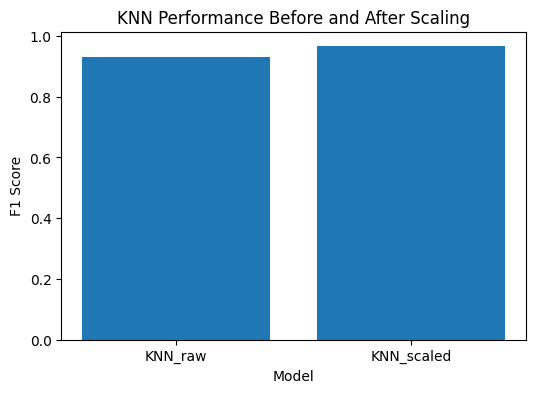

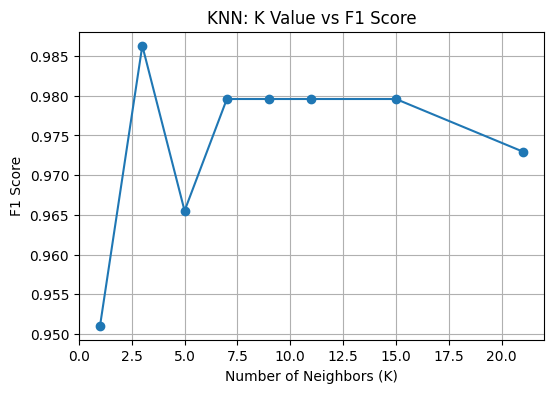

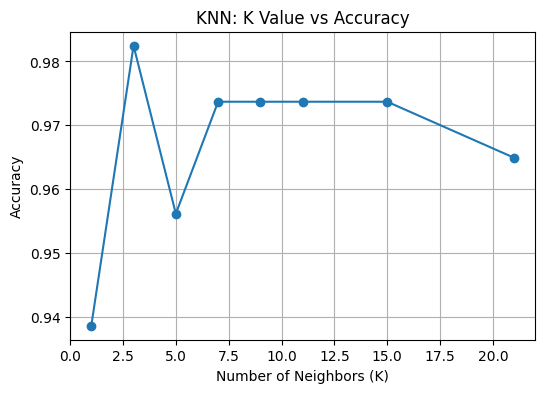

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

#1.加载数据
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target names:", target_names)

#2.划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#3.先训练一个未标准化KNN
knn_raw = KNeighborsClassifier(n_neighbors=5)

knn_raw.fit(X_train, y_train) #fit作用：保存训练样本和对应标签，方便预测时查找最近邻

y_pred_raw = knn_raw.predict(X_test)
y_proba_raw = knn_raw.predict_proba(X_test)[:, 1]

#4.再训练一个标准化KNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)

knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)
y_proba_scaled = knn_scaled.predict_proba(X_test_scaled)[:, 1]

#5.定义评价函数
def evaluate_classifier(y_true, y_pred, y_proba=None):
    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }
    
    if y_proba is not None:
        result["roc_auc"] = roc_auc_score(y_true, y_proba)
    
    return result

#6.比较未标准化和标准化结果
raw_result = evaluate_classifier(y_test, y_pred_raw, y_proba_raw)
scaled_result = evaluate_classifier(y_test, y_pred_scaled, y_proba_scaled)

comparison_df = pd.DataFrame([
    {"model": "KNN_raw", **raw_result}, ## **raw_result为字典合并写法，输出raw_result
    {"model": "KNN_scaled", **scaled_result}
])

print(comparison_df)

#7.尝试不同K值
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

k_results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    result = evaluate_classifier(y_test, y_pred, y_proba)
    
    k_results.append({
        "k": k,
        **result
    })

k_results_df = pd.DataFrame(k_results)

print(k_results_df)

#8.可视化诊断
#标准化前后F1对比图
#作用：标准化有没有改善 KNN 表现？
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(comparison_df["model"], comparison_df["f1"])

ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.set_title("KNN Performance Before and After Scaling")

plt.show()

#K值与F1的关系图
#作用：哪个K值下模型表现较好；K太小或太大时表现如何变化？
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(k_results_df["k"], k_results_df["f1"], marker="o")

ax.set_xlabel("Number of Neighbors (K)")
ax.set_ylabel("F1 Score")
ax.set_title("KNN: K Value vs F1 Score")

ax.grid(True)

plt.show()

#K值与Accuracy的关系图
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(k_results_df["k"], k_results_df["accuracy"], marker="o")

ax.set_xlabel("Number of Neighbors (K)")
ax.set_ylabel("Accuracy")
ax.set_title("KNN: K Value vs Accuracy")

ax.grid(True)

plt.show()

## 算法名称：K 近邻算法 K-Nearest Neighbors, KNN

一、适用任务  
KNN 可用于分类和回归任务。分类任务中，KNN 根据样本附近 K 个最近邻的类别投票决定预测类别；回归任务中，可以根据最近邻目标值的平均值进行预测。本阶段主要用于分类任务。  

二、核心思想  
KNN 的基本假设是相似样本具有相似标签。对于一个待预测样本，算法先计算它与训练集中所有样本的距离，找到距离最近的 K 个样本，再根据这 K 个邻居的类别多数投票确定预测类别。  

三、数学形式  
常用距离为欧氏距离：  
distance(x, z) = sqrt((x1-z1)^2 + (x2-z2)^2 + ... + (xp-zp)^2)  

分类规则：  
预测类别 = K 个最近邻中出现次数最多的类别。  

四、sklearn 实现  
from sklearn.neighbors import KNeighborsClassifier  

model = KNeighborsClassifier(n_neighbors=5)  
model.fit(X_train_scaled, y_train)  
y_pred = model.predict(X_test_scaled)  
y_proba = model.predict_proba(X_test_scaled)[:, 1]  

五、关键参数  
n_neighbors：邻居数量 K。K 太小，模型容易对噪声敏感，可能过拟合；K 太大，模型过于平滑，可能欠拟合。  
weights：邻居投票权重。uniform 表示所有邻居等权重，distance 表示距离越近权重越大。  
metric：距离度量方式，默认常用 Minkowski 距离；在 p=2 时相当于欧氏距离。  

六、常用评价指标  
Accuracy：整体预测正确率。  
Precision：预测为正类的样本中真实为正类的比例。  
Recall：真实正类中被识别出来的比例。  
F1：Precision 和 Recall 的综合指标。  
ROC AUC：模型区分正负类的整体能力。  

七、关键可视化  
1. 标准化前后指标对比图：观察标准化是否改善 KNN 表现。  
2. K 值 vs F1 曲线：观察不同 K 值下模型表现变化，辅助选择合适 K。  

八、优点   
1. 思想简单，容易理解。  
2. 不需要显式训练复杂参数。  
3. 对非线性分类边界有一定适应能力。  
4. 适合作为基础分类模型和教学模型。  

九、缺点  
1. 对特征尺度非常敏感，通常必须标准化。  
2. 预测时需要计算与训练样本的距离，数据量大时预测较慢。  
3. 对无关特征和噪声特征较敏感。  
4. K 值选择对模型表现影响较大。  
5. 高维数据中距离可能变得不可靠。  

十、比赛使用建议  
KNN 可作为分类 baseline 之一，尤其适合用于理解标准化和 K 值选择。但在大规模、高维、噪声较多的数据中，KNN 往往不如树模型和集成模型稳定。使用 KNN 时应先进行标准化，并通过验证集或交叉验证选择合适的 n_neighbors。

# Day 6：Decision Tree决策树

X shape: (569, 30)
y shape: (569,)
Target names: ['malignant' 'benign']
Full Tree Train Accuracy: 1.0
Full Tree Test Accuracy: 0.9122807017543859
Full Tree Test F1: 0.9285714285714286
Full Tree ROC AUC: 0.9156746031746031
Pruned Tree Train Accuracy: 0.9758241758241758
Pruned Tree Test Accuracy: 0.9385964912280702
Pruned Tree Test F1: 0.9517241379310345
Pruned Tree ROC AUC: 0.9446097883597884
           model  train_accuracy  test_accuracy   test_f1  test_auc
0      Full Tree        1.000000       0.912281  0.928571  0.915675
1  Max Depth = 3        0.975824       0.938596  0.951724  0.944610


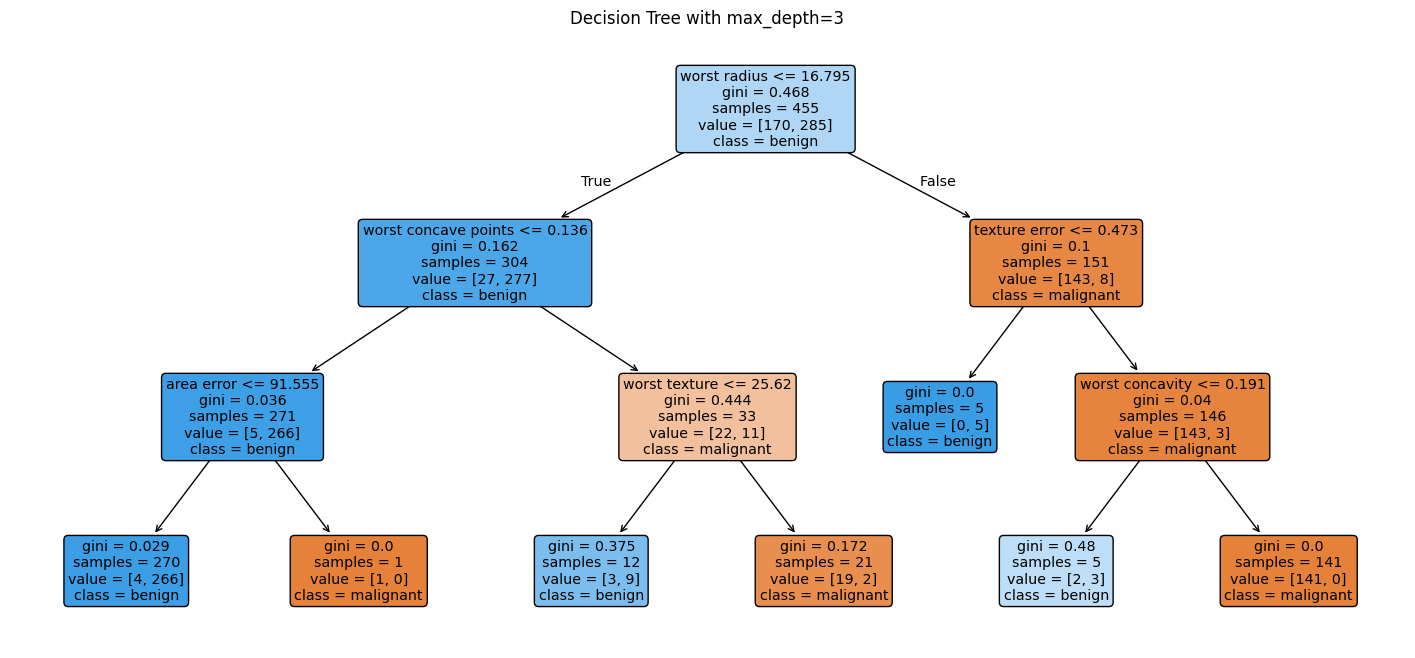

   max_depth  train_accuracy  test_accuracy
0          1        0.923077       0.921053
1          2        0.958242       0.894737
2          3        0.975824       0.938596
3          4        0.986813       0.938596
4          5        0.993407       0.921053
5          6        0.997802       0.912281
6          7        1.000000       0.912281
7          8        1.000000       0.912281
8          9        1.000000       0.912281
9         10        1.000000       0.912281


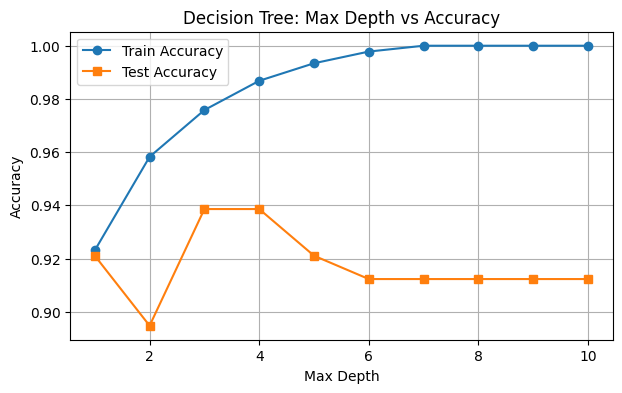

                 feature  importance
20          worst radius    0.763804
27  worst concave points    0.127061
11         texture error    0.047673
21         worst texture    0.033652
26       worst concavity    0.017869
13            area error    0.009940
0            mean radius    0.000000
16       concavity error    0.000000
28        worst symmetry    0.000000
25     worst compactness    0.000000


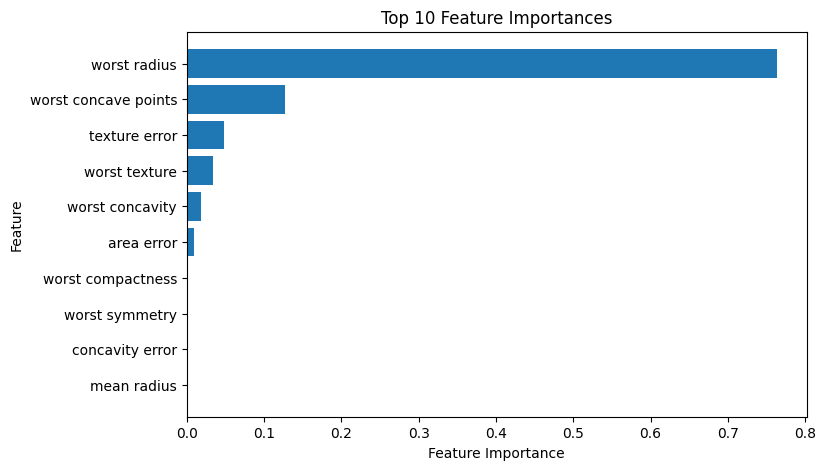

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

#1.加载数据
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target names:", target_names)

#2.划分数据
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#3.先训练一棵完全不限制的树
tree_full = DecisionTreeClassifier(
    random_state=42
)

tree_full.fit(X_train, y_train)

#4.预测
y_train_pred_full = tree_full.predict(X_train)
y_test_pred_full = tree_full.predict(X_test)

y_test_proba_full = tree_full.predict_proba(X_test)[:, 1]

#5.评价模型
train_acc_full = accuracy_score(
    y_train,
    y_train_pred_full
)

test_acc_full = accuracy_score(
    y_test,
    y_test_pred_full
)

test_f1_full = f1_score(
    y_test,
    y_test_pred_full
)

test_auc_full = roc_auc_score(
    y_test,
    y_test_proba_full
)

print("Full Tree Train Accuracy:", train_acc_full)
print("Full Tree Test Accuracy:", test_acc_full)
print("Full Tree Test F1:", test_f1_full)
print("Full Tree ROC AUC:", test_auc_full)

#6.再训练一棵限制深度的树
tree_pruned = DecisionTreeClassifier(
    max_depth=3, #最大深度，表示树最多长到 3 层左右的限制结构
    random_state=42
)

tree_pruned.fit(X_train, y_train)

#7.预测限制后的树
y_train_pred_pruned = tree_pruned.predict(X_train)
y_test_pred_pruned = tree_pruned.predict(X_test)

y_test_proba_pruned = tree_pruned.predict_proba(X_test)[:, 1]

train_acc_pruned = accuracy_score(
    y_train,
    y_train_pred_pruned
)

test_acc_pruned = accuracy_score(
    y_test,
    y_test_pred_pruned
)

test_f1_pruned = f1_score(
    y_test,
    y_test_pred_pruned
)

test_auc_pruned = roc_auc_score(
    y_test,
    y_test_proba_pruned
)

print("Pruned Tree Train Accuracy:", train_acc_pruned)
print("Pruned Tree Test Accuracy:", test_acc_pruned)
print("Pruned Tree Test F1:", test_f1_pruned)
print("Pruned Tree ROC AUC:", test_auc_pruned)

#8.建一个比较表
comparison_df = pd.DataFrame([
    {
        "model": "Full Tree",
        "train_accuracy": train_acc_full,
        "test_accuracy": test_acc_full,
        "test_f1": test_f1_full,
        "test_auc": test_auc_full
    },
    {
        "model": "Max Depth = 3",
        "train_accuracy": train_acc_pruned,
        "test_accuracy": test_acc_pruned,
        "test_f1": test_f1_pruned,
        "test_auc": test_auc_pruned
    }
])

print(comparison_df)

#9.可视化诊断
#直接画决策树图
fig, ax = plt.subplots(figsize=(18, 8))

plot_tree(
    tree_pruned, #要画哪一棵树
    feature_names=feature_names, #让节点显示真实特征名称
    class_names=target_names,
    filled=True, #按照类别给节点填色；颜色越纯，节点类别越纯
    rounded=True, #让节点框变成圆角
    ax=ax #把树画到我们通过 fig, ax = plt.subplots() 创建的这个 Axes 上
)

ax.set_title("Decision Tree with max_depth=3")

plt.show()

#max_depth 对模型的影响图
#树越来越深的时候：训练集表现怎么变？测试集表现怎么变？
#作用：树深度如何影响过拟合？
depth_values = range(1, 11)

depth_results = []

for depth in depth_values:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    depth_results.append({
        "max_depth": depth,
        "train_accuracy": accuracy_score(
            y_train,
            train_pred
        ),
        "test_accuracy": accuracy_score(
            y_test,
            test_pred
        )
    })

depth_results_df = pd.DataFrame(depth_results)

print(depth_results_df)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    depth_results_df["max_depth"],
    depth_results_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    depth_results_df["max_depth"],
    depth_results_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy")
ax.set_title("Decision Tree: Max Depth vs Accuracy")

ax.legend()
ax.grid(True)

plt.show()

#Feature Importance图
#模型主要使用哪些特征？
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_pruned.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(10))

top10 = importance_df.head(10).sort_values(
    "importance"
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    top10["feature"],
    top10["importance"]
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("Top 10 Feature Importances")

plt.show()

## 算法名称：决策树  
英文名称：Decision Tree  

一、适用任务  

决策树可以用于分类和回归任务。本阶段主要掌握决策树分类。  

二、核心思想  

决策树通过不断根据特征设置条件，将样本逐步划分为更纯的子节点。  

模型在每个节点寻找合适的特征和切分点，使分裂后的类别不纯度尽可能降    

三、节点类型  

Root Node：  
根节点，整棵树的起点。  

Internal Node：  
内部节点，继续根据特征条件进行分裂。  

Leaf Node：  
叶节点，不再继续分裂，直接输出预测结果。  

四、常用划分指标  

Gini impurity：  

Gini = 1 - Σpk²  

Gini 越小，表示节点越纯。  

当 Gini=0 时，节点中所有样本属于同一个类别。  

五、sklearn 实现  

from sklearn.tree import DecisionTreeClassifier  

model = DecisionTreeClassifier(  
    max_depth=3,  
    random_state=42  
)  

model.fit(X_train, y_train)  

y_pred = model.predict(X_test)  

y_proba = model.predict_proba(  
    X_test  
)[:, 1]  

六、关键参数  

max_depth：  
控制树的最大深度。  
过小可能欠拟合，过大可能过拟合。  

min_samples_split：  
一个节点至少包含多少样本才允许继续分裂。  

min_samples_leaf：  
叶节点允许保留的最少样本数量。  

criterion：  
节点划分标准。  
常用 gini 和 entropy。  

七、数据预处理  

决策树通常不需要进行特征标准化。  

因为决策树根据单个特征的阈值进行切分，而不是根据不同特征之间的距离进行计算。  

八、常用评价指标  

Accuracy  
Precision  
Recall  
F1  
ROC AUC  
Confusion Matrix  

九、关键可视化  

1. 决策树结构图  
用于解释模型具体分裂过程。  

2. max_depth vs Train/Test Score  
用于观察树复杂度变化以及过拟合情况。  

3. Feature Importance  
用于观察树模型主要使用哪些特征进行分裂。  

十、优点  

1. 模型直观，可解释性较强。  
2. 可以处理非线性关系。  
3. 不需要标准化。  
4. 可以自动学习特征之间的非线性划分。  
5. 可以提供特征重要性。  

十一、缺点  

1. 单棵决策树非常容易过拟合。  
2. 对训练数据的小变化可能较敏感。  
3. 树过深时泛化能力可能较差。  
4. 特征重要性可能存在偏差。  
5. 单棵树的预测性能通常不如随机森林、GBDT 等集成模型。  

十二、比赛使用建议  

决策树可以作为非线性分类 baseline。  

使用时不建议直接使用无限制深度的树，应通过交叉验证选择 max_depth、min_samples_leaf 等参数。  

决策树更重要的价值在于理解树模型基本思想，因为随机森林、GBDT、XGBoost、LightGBM 等重要算法都建立在决策树基础之上。  

# Day 7: Random Forest随机森林

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.956140350877193
Random Forest Test Precision: 0.958904109589041
Random Forest Test Recall: 0.9722222222222222
Random Forest Test F1: 0.9655172413793104
Random Forest ROC AUC: 0.9937169312169312
                   model  test_accuracy   test_f1  test_auc
0     Full Decision Tree       0.912281  0.928571  0.915675
1  Decision Tree depth=3       0.938596  0.951724  0.944610
2          Random Forest       0.956140  0.965517  0.993717


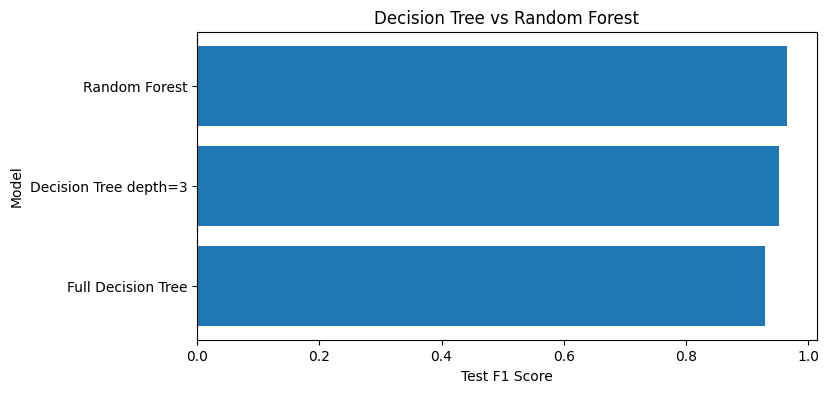

   n_estimators  train_accuracy  test_accuracy
0             1        0.971429       0.947368
1             5        0.991209       0.938596
2            10        0.995604       0.938596
3            20        1.000000       0.956140
4            50        1.000000       0.956140
5           100        1.000000       0.956140
6           200        1.000000       0.956140
7           300        1.000000       0.947368


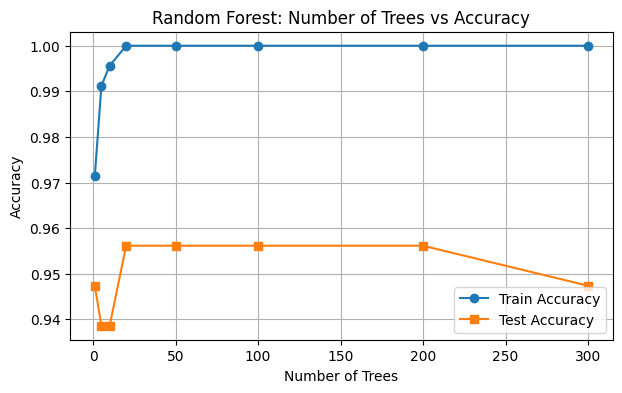

                 feature  importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


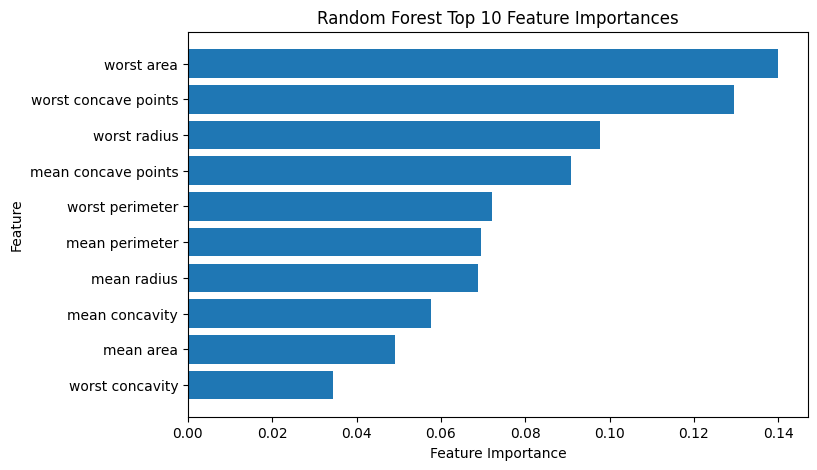

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#1.数据读取与划分
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#2.先训练一个基础 Random Forest
rf = RandomForestClassifier(
    n_estimators=100, #100棵决策树
    random_state=42,
    n_jobs=-1 #尽可能使用可用 CPU 核心并行计算
)

rf.fit(X_train, y_train)

#3.预测
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

y_test_proba = rf.predict_proba(X_test)[:, 1] #benign

#4.评价模型
train_acc = accuracy_score(
    y_train,
    y_train_pred
)

test_acc = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_auc = roc_auc_score(
    y_test,
    y_test_proba
)

print("Random Forest Train Accuracy:", train_acc)
print("Random Forest Test Accuracy:", test_acc)
print("Random Forest Test Precision:", test_precision)
print("Random Forest Test Recall:", test_recall)
print("Random Forest Test F1:", test_f1)
print("Random Forest ROC AUC:", test_auc)

#5.建立模型比较表
comparison_df = pd.DataFrame([
    {
        "model": "Full Decision Tree",
        "test_accuracy": 0.9122807017543859,
        "test_f1": 0.9285714285714286,
        "test_auc": 0.9156746031746031
    },
    {
        "model": "Decision Tree depth=3",
        "test_accuracy": 0.9385964912280702,
        "test_f1": 0.9517241379310345,
        "test_auc": 0.9446097883597884
    },
    {
        "model": "Random Forest",
        "test_accuracy": test_acc,
        "test_f1": test_f1,
        "test_auc": test_auc
    }
])

print(comparison_df)

#6.可视化诊断
#从单棵树变成森林以后，当前数据上的泛化性能发生了什么？
plot_df = comparison_df.sort_values(
    "test_f1"
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    plot_df["model"],
    plot_df["test_f1"]
)

ax.set_xlabel("Test F1 Score")
ax.set_ylabel("Model")
ax.set_title("Decision Tree vs Random Forest")

plt.show()

#第二张图：树的数量 n_estimators
n_values = [
    1, 5, 10, 20, 50,
    100, 200, 300
]

n_results = []

for n in n_values:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    n_results.append({
        "n_estimators": n,
        "train_accuracy": accuracy_score(
            y_train,
            train_pred
        ),
        "test_accuracy": accuracy_score(
            y_test,
            test_pred
        )
    })

n_results_df = pd.DataFrame(n_results)

print(n_results_df)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    n_results_df["n_estimators"],
    n_results_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    n_results_df["n_estimators"],
    n_results_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_xlabel("Number of Trees")
ax.set_ylabel("Accuracy")
ax.set_title(
    "Random Forest: Number of Trees vs Accuracy"
)

ax.legend()
ax.grid(True)

plt.show()

#第三张图：Random Forest Feature Importance
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(10))

top10 = importance_df.head(10).sort_values(
    "importance"
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    top10["feature"],
    top10["importance"]
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title(
    "Random Forest Top 10 Feature Importances"
)

plt.show()

In [8]:
#sklearn 怎么使用 OOB？
rf_oob = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_oob.fit(X_train, y_train)

print(
    "OOB Score:",
    rf_oob.oob_score_
)

OOB Score: 0.9604395604395605


## 算法名称：随机森林  
英文名称：Random Forest  

一、适用任务  

Random Forest 可以用于分类和回归。  
本阶段重点掌握 Random Forest Classification。  

二、核心思想  

Random Forest 通过 Bootstrap 对训练样本进行有放回抽样，训练多棵决策树；同时在每个节点分裂时随机选择部分特征作为候选，从而增加不同树之间的差异性。  

最终通过综合多棵树的预测结果完成预测。  

三、Bagging 思想  

Bootstrap：  
从原训练数据中进行有放回抽样，构造不同训练子集。  

Aggregating：  
将多个基础模型的预测结果进行聚合。  

Random Forest 可以看作以 Decision Tree 为基学习器，并加入随机特征机制的 Bagging 类集成方法。  

四、两个随机性  

1. 样本随机  
每棵树通过 Bootstrap 得到不同训练样本。  

2. 特征随机  
每个节点分裂时只从随机选择的部分特征中寻找最佳切分。  

目的：  
降低树之间的相关性，提高模型多样性和稳定性。  

五、sklearn 实现  

from sklearn.ensemble import RandomForestClassifier  

model = RandomForestClassifier(  
    n_estimators=100,  
    random_state=42,  
    n_jobs=-1  
)  

model.fit(X_train, y_train)  

y_pred = model.predict(X_test)  

y_proba = model.predict_proba(  
    X_test  
)[:, 1]  

六、关键参数  

n_estimators：  
森林中决策树数量。  
增加树数量通常可以提高模型稳定性，但也会增加计算成本。  

max_depth：  
控制每棵树最大深度。  

min_samples_split：  
节点允许继续分裂所需要的最少样本数。  

min_samples_leaf：  
叶节点允许包含的最少样本数。  

max_features：  
每次节点分裂时允许考虑的特征数量，控制不同树之间的随机性。  

七、是否需要标准化  

Random Forest 通常不需要标准化。  

因为基础模型 Decision Tree 根据单个特征阈值进行划分，而不是依赖不同特征之间的距离。  

八、OOB  

Bootstrap 抽样中，没有被某棵树抽中的样本称为 Out-of-Bag samples。  

可以利用 OOB 样本对 Random Forest 进行内部评价。  

sklearn：  

RandomForestClassifier(  
    oob_score=True  
)  
  
训练后：  

model.oob_score_  

九、Feature Importance  

model.feature_importances_  

表示各特征在森林中降低节点不纯度的相对贡献。  

Feature Importance 不能解释为因果效应。  

十、优点  

1. 通常比单棵决策树泛化能力更强。  
2. 能处理非线性关系。   
3. 通常不需要标准化。  
4. 对噪声和训练样本变化通常比单树更加稳定。  
5. 可以提供 Feature Importance。  
6. 可以并行训练。  

十一、缺点  

1. 可解释性弱于单棵决策树。  
2. 树数量较多时训练和预测成本增加。  
3. 模型体积可能较大。  
4. Feature Importance 可能存在偏差。  
5. 在某些结构化数据任务上可能不如精心调优的 Boosting 模型。  

十二、比赛使用建议  
 
Random Forest 是非常重要的树模型 baseline。  

基本流程：  

数据清洗  
→ Train/Test 划分  
→ Random Forest  
→ Cross Validation  
→ 参数调优  
→ 最终测试集评价  

重点参数：  
n_estimators  
max_depth  
min_samples_split  
min_samples_leaf  
max_features  

# Day8:GDBT梯度下降树

GBDT Train Accuracy: 1.0
GBDT Test Accuracy: 0.956140350877193
GBDT Test Precision: 0.9466666666666667
GBDT Test Recall: 0.9861111111111112
GBDT Test F1: 0.9659863945578231
GBDT ROC AUC: 0.9907407407407408
                   model  test_accuracy   test_f1  test_auc
0  Decision Tree depth=3       0.938596  0.951724  0.944610
1          Random Forest       0.956140  0.965517  0.993717
2                   GBDT       0.956140  0.965986  0.990741


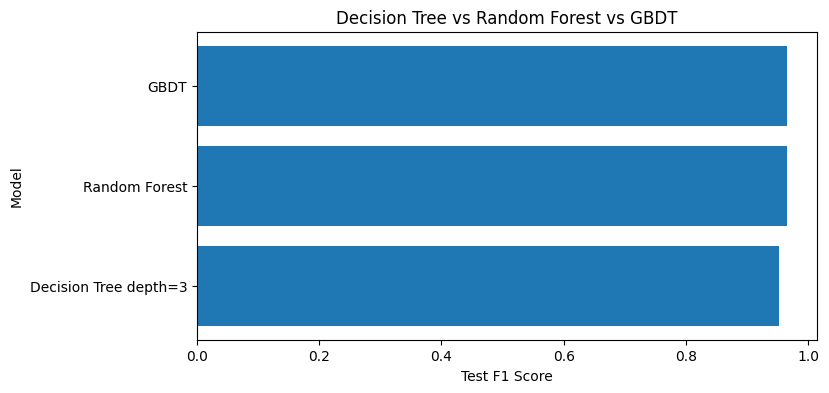

    learning_rate  n_estimators  train_accuracy  test_accuracy
0            0.01            50        0.975824       0.938596
1            0.01           100        0.986813       0.921053
2            0.01           200        0.993407       0.929825
3            0.05            50        0.993407       0.929825
4            0.05           100        1.000000       0.947368
5            0.05           200        1.000000       0.956140
6            0.10            50        1.000000       0.947368
7            0.10           100        1.000000       0.956140
8            0.10           200        1.000000       0.956140
9            0.20            50        1.000000       0.956140
10           0.20           100        1.000000       0.956140
11           0.20           200        1.000000       0.956140


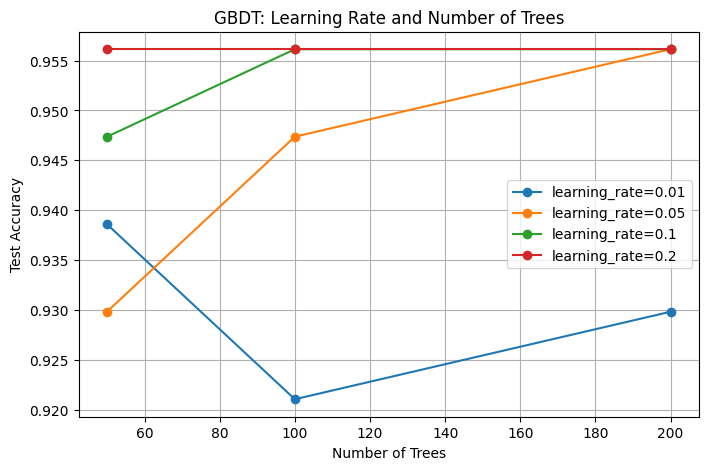

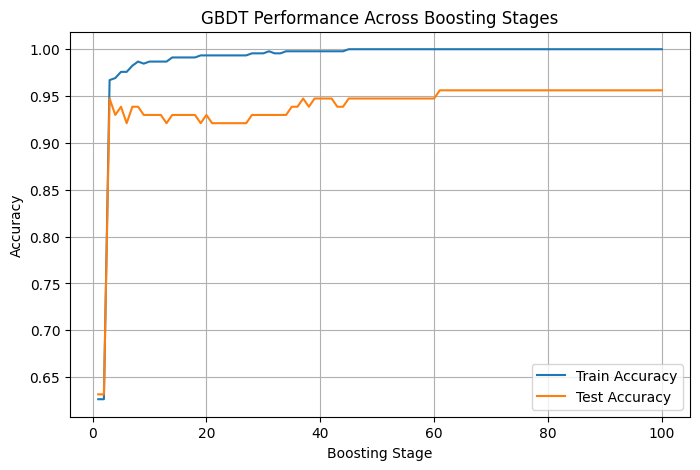

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#1.读取数据
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#2.建立第一个GDBT
gbdt = GradientBoostingClassifier(
    n_estimators=100, #树的数量
    learning_rate=0.1, #学习率
    max_depth=3, #控制每一个弱学习器，也就是每一棵提升树的最大深度
    random_state=42
)

gbdt.fit(X_train, y_train)

#3.预测
y_train_pred = gbdt.predict(X_train)
y_test_pred = gbdt.predict(X_test)

y_test_proba = gbdt.predict_proba(X_test)[:, 1]

#4.评价模型
train_acc = accuracy_score(
    y_train,
    y_train_pred
)

test_acc = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_auc = roc_auc_score(
    y_test,
    y_test_proba
)

print("GBDT Train Accuracy:", train_acc)
print("GBDT Test Accuracy:", test_acc)
print("GBDT Test Precision:", test_precision)
print("GBDT Test Recall:", test_recall)
print("GBDT Test F1:", test_f1)
print("GBDT ROC AUC:", test_auc)

#5.可视化诊断
#Random Forest vs GBDT
comparison_df = pd.DataFrame([
    {
        "model": "Decision Tree depth=3",
        "test_accuracy": 0.9385964912280702,
        "test_f1": 0.9517241379310345,
        "test_auc": 0.9446097883597884
    },
    {
        "model": "Random Forest",
        "test_accuracy": 0.956140350877193,
        "test_f1": 0.9655172413793104,
        "test_auc": 0.9937169312169312
    },
    {
        "model": "GBDT",
        "test_accuracy": test_acc,
        "test_f1": test_f1,
        "test_auc": test_auc
    }
])

print(comparison_df)

plot_df = comparison_df.sort_values(
    "test_f1"
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    plot_df["model"],
    plot_df["test_f1"]
)

ax.set_xlabel("Test F1 Score")
ax.set_ylabel("Model")
ax.set_title(
    "Decision Tree vs Random Forest vs GBDT"
)

plt.show()

#学习率 × 树数量
settings = [
    (0.01, 50),
    (0.01, 100),
    (0.01, 200),
    (0.05, 50),
    (0.05, 100),
    (0.05, 200),
    (0.1, 50),
    (0.1, 100),
    (0.1, 200),
    (0.2, 50),
    (0.2, 100),
    (0.2, 200)
]

results = []

for learning_rate, n_estimators in settings:

    model = GradientBoostingClassifier(
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "train_accuracy": accuracy_score(
            y_train,
            train_pred
        ),
        "test_accuracy": accuracy_score(
            y_test,
            test_pred
        )
    })

results_df = pd.DataFrame(results)

print(results_df)

fig, ax = plt.subplots(figsize=(8, 5))

for learning_rate in sorted(
    results_df["learning_rate"].unique() #取出results_df的learning_rate并去掉重复值
):
    subset = results_df[
        results_df["learning_rate"] == learning_rate
    ]

    ax.plot(
        subset["n_estimators"],
        subset["test_accuracy"],
        marker="o",
        label=f"learning_rate={learning_rate}"
    )

ax.set_xlabel("Number of Trees")
ax.set_ylabel("Test Accuracy")
ax.set_title(
    "GBDT: Learning Rate and Number of Trees"
)

ax.legend()
ax.grid(True)

plt.show()

#真正适合 Boosting 的图————Staged Prediction
#staged_predict：观察 GBDT 在只使用前 1 棵、前 2 棵、前 3 棵……直到前 N 棵树时，模型分别会做出什么预测
#predict=只看最终成绩；staged_predict=看每一学习阶段的成绩变化
staged_train_acc = []
staged_test_acc = []

for train_pred, test_pred in zip(
    gbdt.staged_predict(X_train),
    gbdt.staged_predict(X_test)
):
    staged_train_acc.append(
        accuracy_score(
            y_train,
            train_pred
        )
    )

    staged_test_acc.append(
        accuracy_score(
            y_test,
            test_pred
        )
    )

stages = np.arange(
    1,
    len(staged_train_acc) + 1
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    stages,
    staged_train_acc,
    label="Train Accuracy"
)

ax.plot(
    stages,
    staged_test_acc,
    label="Test Accuracy"
)

ax.set_xlabel("Boosting Stage")
ax.set_ylabel("Accuracy")
ax.set_title(
    "GBDT Performance Across Boosting Stages"
)

ax.legend()
ax.grid(True)

plt.show()

## Day 8 算法名称：  
Gradient Boosting Decision Tree  

简称：  
GBDT  

一、适用任务  

分类与回归。  

sklearn：  
GradientBoostingClassifier  
GradientBoostingRegressor  

二、核心思想  

GBDT 使用多个决策树按照顺序逐步建立模型。  

每一轮根据当前模型的损失函数计算负梯度，并训练新的决策树拟合该负梯度，从而逐步降低整体损失。  

三、核心结构  

初始模型  
↓  
计算当前负梯度  
↓  
训练新树拟合负梯度  
↓  
learning_rate × 新树修正  
↓  
加入已有模型  
↓  
重新计算负梯度  
↓  
继续训练下一棵树  

四、平方误差回归中的特殊情况  

对于平方误差：  

负梯度 = y - prediction  

因此可以直观理解为：  

后一棵树不断拟合前面模型尚未解决的残差。  

五、模型更新  

新模型  =  旧模型  + learning_rate × 新树  

六、关键参数  

n_estimators：  
Boosting 轮数，也可以理解为加入模型的树数量。  

learning_rate：  
控制每棵新树对整体模型的贡献程度。  

max_depth：  
控制每棵弱学习器的最大深度。  

min_samples_split：  
控制节点继续分裂所需最少样本。  

min_samples_leaf：  
控制叶节点最少样本。  
  
subsample：  
每轮训练使用的样本比例。  
小于1时引入随机性。  

七、learning_rate 与 n_estimators  

两者需要联合考虑。  

较小 learning_rate：  
每轮更新较谨慎，  
通常需要更多 n_estimators。  

较大 learning_rate：  
每轮更新较大，  
可能只需要较少树，  
但也可能更容易产生不稳定或过拟合。  

八、是否需要标准化  

GBDT 基于 Decision Tree，    
通常不需要 StandardScaler。  

九、sklearn 模板  

from sklearn.ensemble import GradientBoostingClassifier  

model = GradientBoostingClassifier(  
    n_estimators=100,  
    learning_rate=0.1,  
    max_depth=3,   
    random_state=42  
)  

model.fit(X_train, y_train)  

y_pred = model.predict(X_test)  

y_proba = model.predict_proba(  
    X_test  
)[:, 1]  

十、优点  

1. 能拟合复杂非线性关系。  
2. 通常具有较强预测能力。  
3. 不需要特征标准化。  
4. 可以处理特征交互。  
5. 可以输出 Feature Importance。  

十一、缺点  

1. 树之间串行依赖，经典 GBDT 训练并行能力弱于 Random Forest。  
2. 参数之间存在明显联动。  
3. learning_rate 和 n_estimators 设置不当可能造成欠拟合或过拟合。  
4. 可解释性低于单棵 Decision Tree。  
5. 大数据场景下经典 sklearn GBDT 的训练效率并非最优。  

十二、与 Random Forest 对比  
 
Random Forest：  
Bagging  
树之间相对独立  
主要通过集成降低方差  

GBDT：  
Boosting  
树之间前后依赖  
后一轮不断改善已有模型  
通过逐步优化损失建立强模型  

十三、staged_predict总结  
  
staged_predict 用于获取 GBDT 在不同 boosting stages 下的中间预测结果，从而观察随着树数量增加，模型训练性能和验证性能如何变化。它特别适合分析模型的收敛过程、边际收益以及是否出现过拟合。
